Detected fonts:
DejaVu          -> /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf
Unifont         -> /Users/a../Downloads/Unifont-16.0.04.ttf
Gentium Plus    -> /Users/a../Downloads/GentiumPlus-Regular.ttf


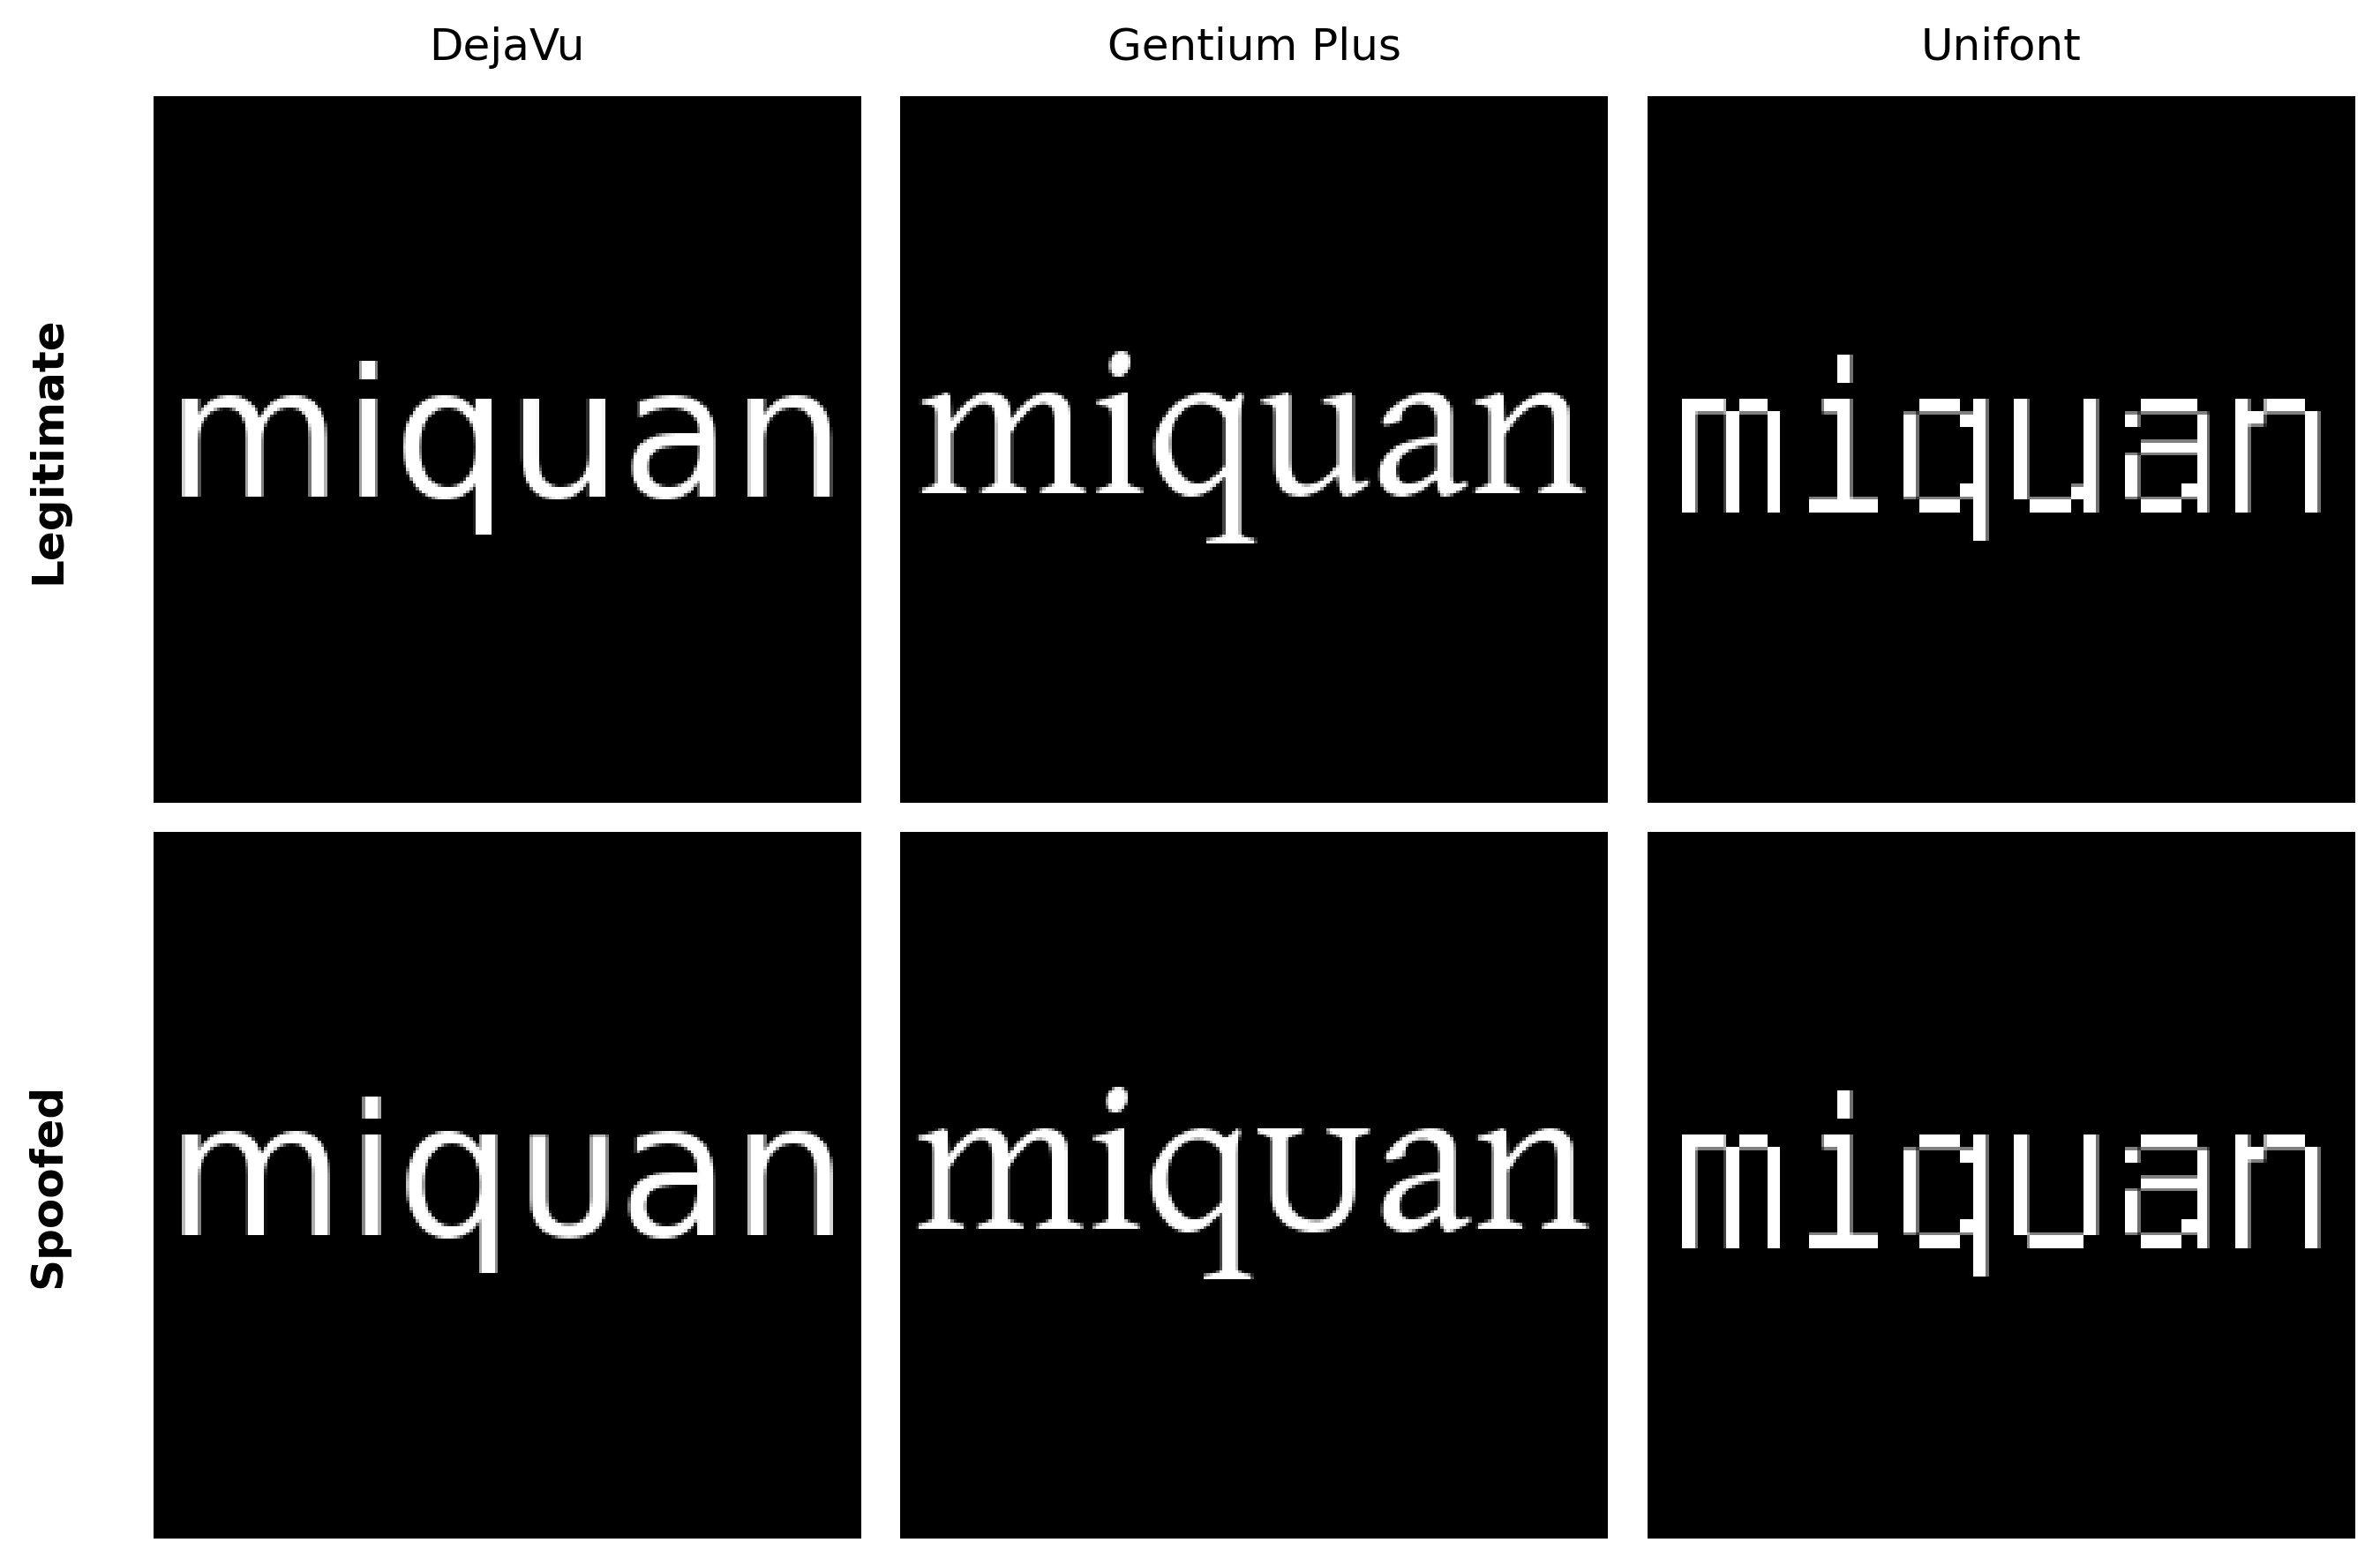

In [40]:
from pathlib import Path
import unicodedata
from functools import lru_cache

import numpy as np
from matplotlib import font_manager
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont


# ==========================================================
# Locate fonts (Notebook-safe)
# ==========================================================
HERE = Path(".").resolve()

def _find_font_file(patterns):
    for pat in patterns:
        hits = sorted(HERE.glob(pat))
        if hits:
            return str(hits[0])
    return None

FONT_PATHS = {
    "DejaVu": font_manager.findfont("DejaVu Sans", fallback_to_default=True),
    "Unifont": _find_font_file(["Unifont*.ttf", "Unifont*.ttf"]),
    "Gentium Plus": _find_font_file(["Gentium*.ttf", "Gentium*.ttf"]),
}

print("Detected fonts:")
for k, v in FONT_PATHS.items():
    print(f"{k:15s} -> {v}")


# ==========================================================
# Font cache (keyed by path + size)
# ==========================================================
@lru_cache(maxsize=4096)
def _get_font(font_path: str, font_size: int):
    try:
        return ImageFont.truetype(font_path, int(font_size))
    except Exception:
        return ImageFont.load_default()

def _measure_text(draw, text, font):
    x0, y0, x1, y1 = draw.textbbox((0, 0), text, font=font)
    return (x1 - x0), (y1 - y0), x0, y0


# ==========================================================
# MAX FIT
# ==========================================================
def _max_fitting_font_size(
    draw,
    text,
    allowed_w,
    allowed_h,
    base_font_size,
    min_font_size,
    max_font_cap,
    font_path,
):
    min_fs = max(1, int(min_font_size))
    cap_fs = max(min_fs, int(max_font_cap))
    base_fs = max(min_fs, min(cap_fs, int(base_font_size)))

    font0 = _get_font(font_path, base_fs)
    w0, h0, _, _ = _measure_text(draw, text, font0)

    if w0 <= 0 or h0 <= 0:
        font = _get_font(font_path, min_fs)
        w, h, x0, y0 = _measure_text(draw, text, font)
        return min_fs, w, h, x0, y0

    scale = min(allowed_w / w0, allowed_h / h0)
    est = int(base_fs * scale)
    est = max(min_fs, min(cap_fs, est))

    def fits(fs):
        font = _get_font(font_path, fs)
        w, h, _, _ = _measure_text(draw, text, font)
        return (w <= allowed_w) and (h <= allowed_h)

    fs = est
    while fs > min_fs and not fits(fs):
        fs -= 1

    if fs == min_fs and not fits(fs):
        font = _get_font(font_path, min_fs)
        w, h, x0, y0 = _measure_text(draw, text, font)
        return min_fs, w, h, x0, y0

    lo = fs
    hi = min(cap_fs, lo + 1)
    while hi < cap_fs and fits(hi):
        lo = hi
        hi = min(cap_fs, hi * 2)

    if fits(hi):
        font = _get_font(font_path, hi)
        w, h, x0, y0 = _measure_text(draw, text, font)
        return hi, w, h, x0, y0

    low, high = lo, hi
    while low + 1 < high:
        mid = (low + high) // 2
        if fits(mid):
            low = mid
        else:
            high = mid

    font = _get_font(font_path, low)
    w, h, x0, y0 = _measure_text(draw, text, font)
    return low, w, h, x0, y0


# ==========================================================
# 224x224 GENERATOR (MULTI-FONT) - UPDATED LOGIC
# ==========================================================
def generate_glyph_image(
    text,
    font_name="DejaVu",
    image_size=(224, 224),
    pad=4,
    min_font_size=1,
    base_font_size=120,
    max_font_cap=1024,
    hd_enabled=True,
    hd_threshold=10,
    hd_min_scale=2,
    hd_max_scale=8,
    hd_target_font_px=28,
):
    text = unicodedata.normalize("NFC", str(text))
    font_path = FONT_PATHS.get(font_name)
    if font_path is None:
        raise ValueError(f"Font {font_name} not found.")

    W, H = int(image_size[0]), int(image_size[1])
    pad = int(pad)
    allowed_w = max(1, W - 2 * pad)
    allowed_h = max(1, H - 2 * pad)

    tmp = Image.new("RGB", (W, H), (0, 0, 0))
    tmp_draw = ImageDraw.Draw(tmp)

    fs_native, _, _, _, _ = _max_fitting_font_size(
        tmp_draw, text, allowed_w, allowed_h,
        base_font_size, min_font_size, max_font_cap,
        font_path,
    )

    use_hd = bool(hd_enabled and (int(fs_native) <= int(hd_threshold)) and (int(hd_max_scale) >= 2))

    if not use_hd:
        img = Image.new("RGB", (W, H), (0, 0, 0))
        draw = ImageDraw.Draw(img)

        fs, w, h, x0, y0 = _max_fitting_font_size(
            draw, text, allowed_w, allowed_h,
            base_font_size, min_font_size, max_font_cap,
            font_path,
        )

        x = (W - w) // 2 - x0
        y = (H - h) // 2 - y0
        draw.text((x, y), text, font=_get_font(font_path, fs), fill=(255, 255, 255))

        meta = {
            "font": font_name,
            "font_path": font_path,
            "fs_native": int(fs_native),
            "fs_used": int(fs),
            "use_hd": False,
            "hd_scale_used": 1,
            "pad": int(pad),
            "allowed": (int(allowed_w), int(allowed_h)),
        }
        return img, meta

    target = max(1, int(hd_target_font_px))
    denom = max(1, int(fs_native))
    needed = int(np.ceil(target / denom))
    S = max(int(hd_min_scale), needed)
    S = min(int(hd_max_scale), max(2, S))

    WR, HR = W * S, H * S
    pad_r = pad * S
    allowed_wr = max(1, WR - 2 * pad_r)
    allowed_hr = max(1, HR - 2 * pad_r)

    img_r = Image.new("RGB", (WR, HR), (0, 0, 0))
    draw_r = ImageDraw.Draw(img_r)

    fs_r, w_r, h_r, x0_r, y0_r = _max_fitting_font_size(
        draw_r, text, allowed_wr, allowed_hr,
        base_font_size * S,
        max(1, min_font_size * S),
        max_font_cap * S,
        font_path,
    )

    x_r = (WR - w_r) // 2 - x0_r
    y_r = (HR - h_r) // 2 - y0_r
    draw_r.text((x_r, y_r), text, font=_get_font(font_path, fs_r), fill=(255, 255, 255))

    img = img_r.resize((W, H), resample=Image.Resampling.LANCZOS)

    meta = {
        "font": font_name,
        "font_path": font_path,
        "fs_native": int(fs_native),
        "fs_used": int(fs_r),
        "use_hd": True,
        "hd_scale_used": int(S),
        "hd_target_font_px": int(hd_target_font_px),
        "pad": int(pad),
        "allowed": (int(allowed_w), int(allowed_h)),
    }
    return img, meta


# ==========================================================
# ONE-SHOT FIGURE (NO SAVING/LOADING IMAGES)
# ==========================================================
def font_comparison_figure(
    legit_text,
    spoof_text,
    fonts=("DejaVu", "Gentium Plus", "Unifont"),
    image_size=(224, 224),
    pad=4,
    hd_enabled=True,
    hd_threshold=10,
    hd_min_scale=2,
    hd_max_scale=12,
    hd_target_font_px=36,
    figsize=(9, 6),
    dpi=300,
    save_prefix="font_comparison_figure",
):
    # Validate fonts exist
    fonts = list(fonts)
    for f in fonts:
        if FONT_PATHS.get(f) is None:
            raise ValueError(f"Font '{f}' not found (FONT_PATHS[{f!r}] is None).")

    rows = [("Legitimate", legit_text), ("Spoofed", spoof_text)]

    fig, axes = plt.subplots(
        nrows=2,
        ncols=len(fonts),
        figsize=figsize,
        dpi=dpi
    )
    if len(fonts) == 1:
        axes = np.array(axes).reshape(2, 1)

    for r, (row_label, text) in enumerate(rows):
        for c, font_name in enumerate(fonts):
            img, meta = generate_glyph_image(
                text,
                font_name=font_name,
                image_size=image_size,
                pad=pad,
                hd_enabled=hd_enabled,
                hd_threshold=hd_threshold,
                hd_min_scale=hd_min_scale,
                hd_max_scale=hd_max_scale,
                hd_target_font_px=hd_target_font_px,
            )
            ax = axes[r, c]
            ax.imshow(img)
            ax.axis("off")

            # Optional: if you want to inspect per-cell font sizing, uncomment:
            # print(row_label, font_name, meta)

    # Column titles (top row)
    for i, title in enumerate(fonts):
        axes[0, i].set_title(title, fontsize=12, pad=10)

    # Row labels on the left
    for r, (row_label, _) in enumerate(rows):
        axes[r, 0].annotate(
            row_label,
            xy=(-0.15, 0.5),
            xycoords="axes fraction",
            rotation=90,
            va="center",
            ha="center",
            fontsize=12,
            fontweight="bold"
        )

    plt.tight_layout()

    # Save final outputs (only the combined figure)
    plt.savefig(f"{save_prefix}.pdf", bbox_inches="tight")
    plt.savefig(f"{save_prefix}.png", bbox_inches="tight", dpi=dpi)

    plt.show()


# ==========================================================
# RUN
# ==========================================================
legit = "miquan"      # <-- replace
spoof = "miqᴜan"      # <-- replace (example; put your spoof string)

font_comparison_figure(
    legit_text=legit,
    spoof_text=spoof,
    fonts=("DejaVu", "Gentium Plus", "Unifont"),
    pad=4,
    hd_enabled=True,
    hd_threshold=10,
    hd_min_scale=2,
    hd_max_scale=12,
    hd_target_font_px=36,
    save_prefix="font_comparison_figure",
)